# Autocall Phoenix: pricing and structuring walkthrough

This notebook reproduces the core workflow of an equity structuring desk on an
**autocall Phoenix** on the Euro Stoxx 50:

1. **The product**: term sheet and payoff mechanics
2. **Pricing method**: risk-neutral Monte Carlo on observation dates
3. **Validation**: limit cases and convergence
4. **Results**: par coupon sensitivities and product life statistics

All pricing logic lives in the `pricer` package (`src/pricer/`); this notebook only calls it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pricer.models import simulate_gbm_paths
from pricer.products import phoenix_cashflows
from pricer.monte_carlo import price_phoenix
from pricer.solver import phoenix_par_coupon

# Market and product parameters
S0, r, sigma = 100.0, 0.03, 0.20
TIMES = [1, 2, 3, 4, 5]   # annual observation dates (years)
COUPON = 0.08             # 8% per year, with memory
NOMINAL = 1000.0

## 1. The product

| Feature | Value |
|---|---|
| Underlying | Euro Stoxx 50 (initial level = 100%) |
| Nominal | 1,000 € |
| Maximum maturity | 5 years, annual observations |
| Autocall barrier | 100% |
| Coupon barrier | 70%, coupon of 8% p.a. with memory |
| Protection barrier | 60%, observed at maturity only |

**At each observation date (years 1 to 4):**
- Index ≥ 100%: **early redemption**: nominal + coupon (+ memorized coupons).
- 70% ≤ index < 100%: coupon paid (+ memorized coupons), the product continues.
- Index < 70%: no coupon, it is memorized.

**At maturity (year 5):** nominal + coupons if the index is ≥ 70%; nominal only
between 60% and 70%; below 60%, the client takes the full loss (nominal × index performance).

**What the client sells:** in exchange for the conditional coupons, the client sells the bank
a **down-and-in put** at 60%: they bear the index loss if it ends below the protection barrier.
The payoff depends on the whole path (early redemption, memory), so there is no simple
closed form: we price it by Monte Carlo.

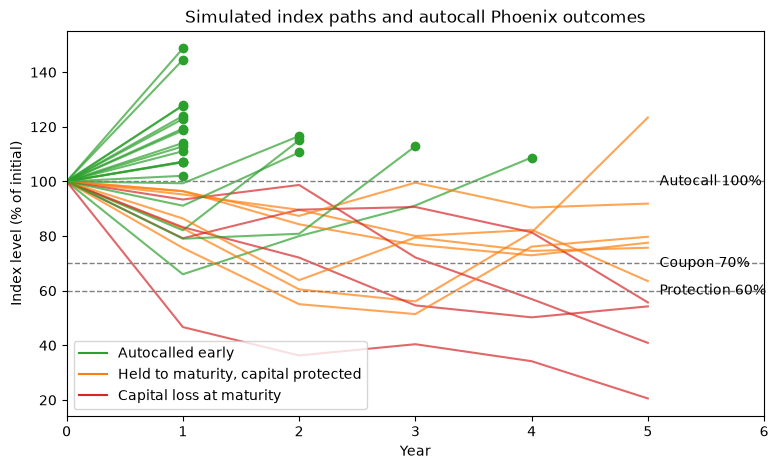

In [3]:
n_show = 30
paths = simulate_gbm_paths(S0, r, sigma, TIMES, n_paths=n_show, seed=23)
flows = phoenix_cashflows(paths, S0, COUPON)
last = flows[:, -1]

# Outcome of each path: autocalled, protected at maturity, or capital loss
colors = np.where(last == 0, "tab:green", np.where(last < 600, "tab:red", "tab:orange"))

# Date at which each product ends (first autocall date, or maturity)
called = paths[:, :-1] >= S0
end_date = np.where(called.any(axis=1), called.argmax(axis=1) + 1, 5) # Each path : date of first call if it was called, otherwise maturity (5)

full = np.column_stack([np.full(n_show, S0), paths])   # add the starting point S0 to paths

fig, ax = plt.subplots(figsize=(9, 5))
for path, end, color in zip(full, end_date, colors):
    ax.plot(range(end + 1), path[:end + 1], color=color, alpha=0.7)
    if end < 5:
        ax.plot(end, path[end], "o", color=color)

for level, label in [(100, "Autocall 100%"), (70, "Coupon 70%"), (60, "Protection 60%")]:
    ax.axhline(level, linestyle="--", color="gray", linewidth=1)
    ax.text(5.1, level, label, va="center")

# Empty lines, used only to build the legend
ax.plot([], [], color="tab:green", label="Autocalled early")
ax.plot([], [], color="tab:orange", label="Held to maturity, capital protected")
ax.plot([], [], color="tab:red", label="Capital loss at maturity")

ax.set_xlim(0, 6)
ax.set_xlabel("Year")
ax.set_ylabel("Index level (% of initial)")
ax.set_title("Simulated index paths and autocall Phoenix outcomes")
ax.legend(loc="lower left")
plt.show()

## 2. Pricing method

Under the risk-neutral measure, the index is simulated at the observation dates only,
one step at a time with independent shocks:

$$S_{t+\Delta t} = S_t \exp\Big[\big(r - \tfrac{\sigma^2}{2}\big)\Delta t + \sigma\sqrt{\Delta t}\,Z\Big],
\qquad Z \sim \mathcal{N}(0,1)$$

For each path, the cash flows are discounted at their own payment date, and the
fair value is the average over all paths (N):

$$V = \frac{1}{N}\sum_{i=1}^{N} \sum_{t} \text{CF}^{(i)}_t \, e^{-rt}$$

The **par coupon** is the coupon that makes the fair value equal to the nominal. It is
found with a root solver (`brentq`), using the **same simulated paths** for every trial
coupon (common random numbers), so that the value is a smooth function of the coupon.

In [7]:
value, se = price_phoenix(S0, r, sigma, TIMES, coupon=COUPON)
par = phoenix_par_coupon(S0, r, sigma, TIMES)
with_margin = phoenix_par_coupon(S0, r, sigma, TIMES, target=0.985 * NOMINAL)


print(f"Fair value with an 8% coupon: {value:.2f} ± {1.96 * se:.2f}€ (95% CI), for a nominal of {NOMINAL:.0f}€")
print(f"Par coupon (value = nominal):  {par:.2%}")
print(f"Coupon with a 1.5% margin:     {with_margin:.2%}")

Fair value with an 8% coupon: 1050.43 ± 0.99€ (95% CI), for a nominal of 1000€
Par coupon (value = nominal):  5.34%
Coupon with a 1.5% margin:     4.55%


**Interpretation.** With these market parameters, an 8% coupon is too generous: hedging
the product would cost the bank about 1,050€ for a note sold at 1,000€. The coupon
the bank can actually offer is the par coupon (about 5.3%), or about 4.6% after a 1.5% margin.

Real-life autocalls often show higher coupons because of effects this simple model leaves out:
dividends, the issuer's funding spread, or riskier underlyings
(single stocks, worst-of baskets). Section 4 shows how the main structuring levers move the coupon.

## 3. Validation

There is no closed form for this product, so the pricer is validated in three ways
(see `tests/`):

- **Hand calculations**: cash flows of term-sheet scenarios checked date by date.
- **Limit cases** where the product collapses to something with a known value:
  - never called, always protected → a zero-coupon bond worth $1000\,e^{-5r}$;
  - never called, never protected → the index itself, worth the nominal.
- **Convergence**: the Monte Carlo error shrinks as $1/\sqrt{N}$.

In [9]:
zc, _ = price_phoenix(S0, r, sigma, TIMES, coupon=0.0,
                      autocall_barrier=np.inf, protection_barrier=0.0)
idx, idx_se = price_phoenix(S0, r, sigma, TIMES, coupon=0.0,
                            autocall_barrier=np.inf, protection_barrier=np.inf)

print(f"Never called, always protected: {zc:8.2f}   vs zero-coupon bond {NOMINAL * np.exp(-r * 5):8.2f}")
print(f"Never called, never protected:  {idx:8.2f} ± {1.96 * idx_se:.2f}   vs nominal {NOMINAL:8.2f}")

Never called, always protected:   860.71   vs zero-coupon bond   860.71
Never called, never protected:    999.88 ± 2.92   vs nominal  1000.00


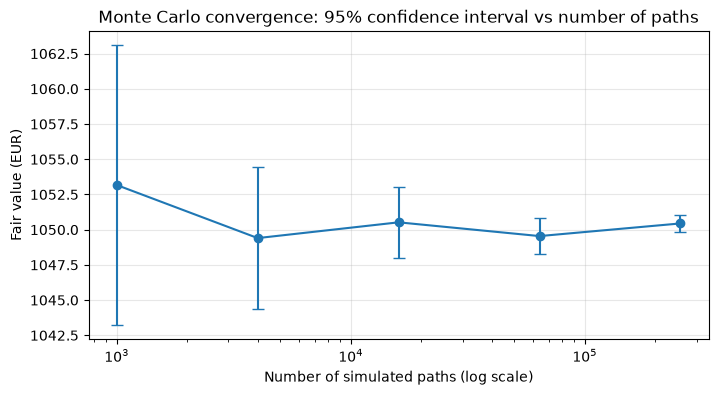

In [12]:
# Monte carlo convergence

n_list = [1_000, 4_000, 16_000, 64_000, 256_000]
results = [price_phoenix(S0, r, sigma, TIMES, coupon=COUPON, n_paths=n) for n in n_list]
values = np.array([v for v, _ in results])
errors = np.array([1.96 * s for _, s in results])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(n_list, values, yerr=errors, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of simulated paths (log scale)")
ax.set_ylabel("Fair value (EUR)")
ax.set_title("Monte Carlo convergence: 95% confidence interval vs number of paths")
ax.grid(True, alpha=0.3)
plt.show()